In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix
from collections import Counter

np.random.seed(42)

In [3]:
# load hierarchical model
with open('../output/hierarchical_model.pkl', 'rb') as f:
    model_components = pickle.load(f)

group_a_detector = model_components['group_a_detector']
group_c_detector = model_components['group_c_detector']
classifier_012 = model_components['classifier_012']
classifier_45 = model_components['classifier_45']
feature_cols = model_components['features']

print("Hierarchical model loaded")

# load features
train_df = pd.read_csv('../output/features_train.csv')
test_df = pd.read_csv('../output/features_test.csv')

X_train = train_df[feature_cols].values
y_train = train_df['label'].values
X_test = test_df[feature_cols].values
y_test = test_df['label'].values

print(f"Train: {len(X_train):,}")
print(f"Test: {len(X_test):,}")

Hierarchical model loaded
Train: 289,263
Test: 72,316


In [5]:
# load classification rules
with open('../output/classification_rules.pkl', 'rb') as f:
    classification_rules = pickle.load(f)

# load discretization info
with open('../output/bin_info.pkl', 'rb') as f:
    bin_info = pickle.load(f)

print(f"Classification rules: {len(classification_rules)}")
print(f"Discretization bins: {len(bin_info)} features")

# check rule distribution
print("\nRules per class:")
for cls in range(6):
    count = sum(1 for r in classification_rules if r['predicts_class'] == cls)
    print(f"  Class {cls}: {count}")

Classification rules: 149
Discretization bins: 15 features

Rules per class:
  Class 0: 10
  Class 1: 26
  Class 2: 29
  Class 3: 6
  Class 4: 57
  Class 5: 21


In [7]:
# hierarchical predictions
def predict_hierarchical(X, threshold=0.1):
    preds = np.zeros(len(X), dtype=int)
    
    is_a = group_a_detector.predict(X)
    prob_c = group_c_detector.predict_proba(X)[:, 1]
    
    for i in range(len(X)):
        if is_a[i] == 1:
            preds[i] = classifier_012.predict(X[i:i+1])[0]
        elif prob_c[i] > threshold:
            preds[i] = classifier_45.predict(X[i:i+1])[0]
        else:
            preds[i] = 3
    
    return preds

hier_pred = predict_hierarchical(X_test)

hier_acc = accuracy_score(y_test, hier_pred)
hier_f1 = f1_score(y_test, hier_pred, average='macro')

print(f"Hierarchical baseline:")
print(f"  Accuracy: {hier_acc*100:.2f}%")
print(f"  Macro F1: {hier_f1:.4f}")

Hierarchical baseline:
  Accuracy: 62.15%
  Macro F1: 0.4895


In [8]:
# discretize test features
def discretize_sample(sample, bin_info):
   
    disc = {}
    for feat_name, value in zip(feature_cols, sample):
        if feat_name not in bin_info:
            continue
        
        thresholds = bin_info[feat_name]['thresholds']
        if not thresholds:
            disc[feat_name] = 0
        else:
            bin_val = np.digitize(value, thresholds)
            disc[feat_name] = bin_val
    
    return disc

# discretize all test samples
print("Discretizing test samples...")
test_discretized = []
for i in range(len(X_test)):
    if i % 10000 == 0:
        print(f"  {i}/{len(X_test)}...", end='\r')
    disc = discretize_sample(X_test[i], bin_info)
    test_discretized.append(disc)

print(f"  {len(X_test)}/{len(X_test)} done")

Discretizing test samples...
  72316/72316 done


In [9]:
# match rules to samples
def get_matching_rules(disc_sample, rules):
    """find all rules that match this sample"""
    # convert to transaction format
    transaction = set()
    for feat, bin_val in disc_sample.items():
        transaction.add(f"{feat}={bin_val}")
    
    # find matching rules
    matching = []
    for rule in rules:
        if rule['pattern'].issubset(transaction):
            matching.append(rule)
    
    return matching



In [10]:
# compute CSV scores for all test samples


all_csv_scores = []

for i, disc in enumerate(test_discretized):
    if i % 5000 == 0:
        print(f"  {i}/{len(test_discretized)}...", end='\r')
    
    # find matching rules
    matching = get_matching_rules(disc, classification_rules)
    
    # compute CSV scores per class
    csv = np.zeros(6)
    for rule in matching:
        cls = rule['predicts_class']
        csv[cls] += rule['confidence'] * rule['lift']
    
    all_csv_scores.append(csv)

all_csv_scores = np.array(all_csv_scores)
print(f"  {len(test_discretized)}/{len(test_discretized)} done")

# check how many samples had rules fire
rules_fired = (all_csv_scores.sum(axis=1) > 0).sum()
print(f"\nSamples with matching rules: {rules_fired:,} ({rules_fired/len(X_test)*100:.1f}%)")

  72316/72316 done

Samples with matching rules: 72,302 (100.0%)


In [11]:
def ensemble(hier_pred, csv_scores, alpha):
   
    preds = []
    
    for i in range(len(hier_pred)):
        votes = np.zeros(6)
        
        # hierarchical vote
        votes[hier_pred[i]] += alpha
        
        # rule votes (only if rules fired)
        total_rule = csv_scores[i].sum()
        if total_rule > 0:
            # normalize rule scores to sum to 1
            rule_proba = csv_scores[i] / total_rule
            votes += (1 - alpha) * rule_proba
        else:
            # no rules fired, give hierarchical full weight
            votes[hier_pred[i]] += (1 - alpha)
        
        preds.append(np.argmax(votes))
    
    return np.array(preds)



In [12]:
# sweep alpha from 0.5 to 1.0
alphas = [0.5, 0.6, 0.7, 0.8, 0.85, 0.9, 0.92, 0.94, 0.96, 0.98, 0.99, 1.0]

results = []

print("Sweeping alpha parameter...")
for alpha in alphas:
    preds = ensemble(hier_pred, all_csv_scores, alpha)
    
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average='macro')
    
    results.append({
        'alpha': alpha,
        'accuracy': acc,
        'f1': f1
    })
    
    print(f"  alpha={alpha:.2f}: Acc={acc*100:.2f}%, F1={f1:.4f}")

# convert to dataframe
results_df = pd.DataFrame(results)

Sweeping alpha parameter...
  alpha=0.50: Acc=62.14%, F1=0.4897
  alpha=0.60: Acc=62.15%, F1=0.4895
  alpha=0.70: Acc=62.15%, F1=0.4895
  alpha=0.80: Acc=62.15%, F1=0.4895
  alpha=0.85: Acc=62.15%, F1=0.4895
  alpha=0.90: Acc=62.15%, F1=0.4895
  alpha=0.92: Acc=62.15%, F1=0.4895
  alpha=0.94: Acc=62.15%, F1=0.4895
  alpha=0.96: Acc=62.15%, F1=0.4895
  alpha=0.98: Acc=62.15%, F1=0.4895
  alpha=0.99: Acc=62.15%, F1=0.4895
  alpha=1.00: Acc=62.15%, F1=0.4895


In [13]:
# find best alpha
best_idx = results_df['f1'].idxmax()
best_alpha = results_df.loc[best_idx, 'alpha']
best_f1 = results_df.loc[best_idx, 'f1']

print(f"\nBest alpha: {best_alpha}")
print(f"Best F1: {best_f1:.4f}")
print(f"Hierarchical F1: {hier_f1:.4f}")
print(f"Improvement: {best_f1 - hier_f1:+.4f}")

# get predictions with best alpha
best_preds = ensemble(hier_pred, all_csv_scores, best_alpha)
best_acc = accuracy_score(y_test, best_preds)

print(f"\nBest ensemble:")
print(f"  Accuracy: {best_acc*100:.2f}%")
print(f"  Macro F1: {best_f1:.4f}")


Best alpha: 0.5
Best F1: 0.4897
Hierarchical F1: 0.4895
Improvement: +0.0002

Best ensemble:
  Accuracy: 62.14%
  Macro F1: 0.4897


In [14]:
# compare per-class F1 scores
class_names = {
    0: "Fully Human",
    1: "Human-AI Polished",
    2: "AI-AI Humanized",
    3: "Human-AI Continued",
    4: "Deeply Mixed",
    5: "AI-Human Edited"
}

print("\nPer-class F1 comparison:")
print(f"{'Class':<8} {'Name':<25} {'Hierarchical':<15} {'Ensemble':<15} {'Diff':<10}")
print("-" * 85)

hier_f1_per_class = []
ens_f1_per_class = []

for cls in range(6):
    mask = (y_test == cls)
    
    # hierarchical
    tp_h = ((hier_pred == cls) & (y_test == cls)).sum()
    fp_h = ((hier_pred == cls) & (y_test != cls)).sum()
    fn_h = ((hier_pred != cls) & (y_test == cls)).sum()
    
    p_h = tp_h / (tp_h + fp_h) if (tp_h + fp_h) > 0 else 0
    r_h = tp_h / (tp_h + fn_h) if (tp_h + fn_h) > 0 else 0
    f1_h = 2*p_h*r_h / (p_h+r_h) if (p_h+r_h) > 0 else 0
    
    # ensemble
    tp_e = ((best_preds == cls) & (y_test == cls)).sum()
    fp_e = ((best_preds == cls) & (y_test != cls)).sum()
    fn_e = ((best_preds != cls) & (y_test == cls)).sum()
    
    p_e = tp_e / (tp_e + fp_e) if (tp_e + fp_e) > 0 else 0
    r_e = tp_e / (tp_e + fn_e) if (tp_e + fn_e) > 0 else 0
    f1_e = 2*p_e*r_e / (p_e+r_e) if (p_e+r_e) > 0 else 0
    
    hier_f1_per_class.append(f1_h)
    ens_f1_per_class.append(f1_e)
    
    diff = f1_e - f1_h
    
    print(f"{cls:<8} {class_names[cls]:<25} {f1_h:<15.3f} {f1_e:<15.3f} {diff:+.3f}")


Per-class F1 comparison:
Class    Name                      Hierarchical    Ensemble        Diff      
-------------------------------------------------------------------------------------
0        Fully Human               0.675           0.675           -0.000
1        Human-AI Polished         0.563           0.563           -0.000
2        AI-AI Humanized           0.692           0.692           -0.000
3        Human-AI Continued        0.591           0.591           -0.000
4        Deeply Mixed              0.340           0.342           +0.002
5        AI-Human Edited           0.075           0.075           +0.000


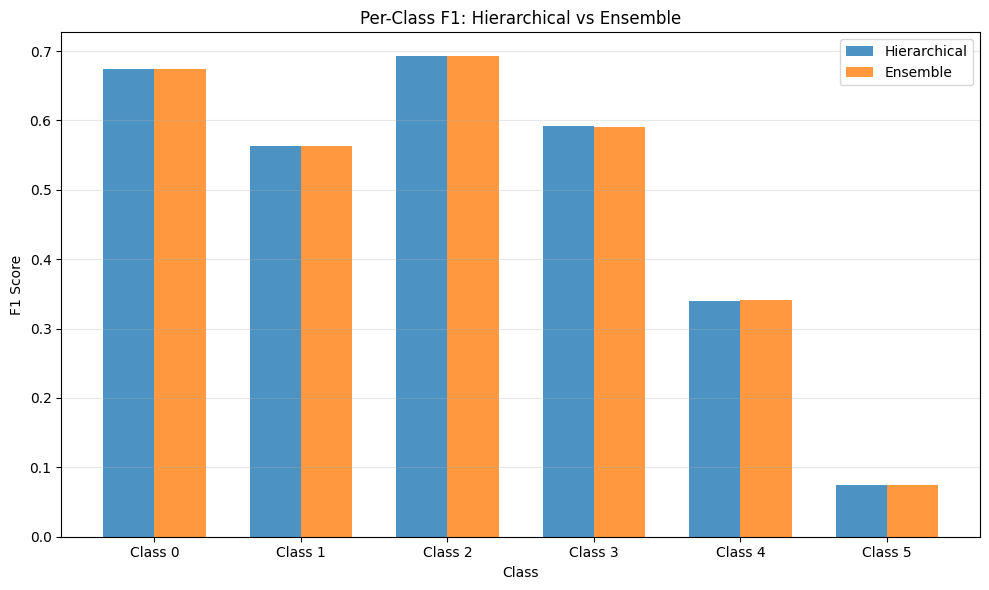

In [15]:
# bar chart comparison
x = np.arange(6)
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - width/2, hier_f1_per_class, width, label='Hierarchical', alpha=0.8)
bars2 = ax.bar(x + width/2, ens_f1_per_class, width, label='Ensemble', alpha=0.8)

ax.set_xlabel('Class')
ax.set_ylabel('F1 Score')
ax.set_title('Per-Class F1: Hierarchical vs Ensemble')
ax.set_xticks(x)
ax.set_xticklabels([f'Class {i}' for i in range(6)])
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()

plt.show()



In [ ]:
# where do predictions differ?
differences = (hier_pred != best_preds)
n_diff = differences.sum()

print(f"\nPredictions changed: {n_diff:,} ({n_diff/len(X_test)*100:.1f}%)")

# breakdown by true class
print("\nChanges by true class:")
for cls in range(6):
    mask = (y_test == cls) & differences
    n_changed = mask.sum()
    total = (y_test == cls).sum()
    
    if total > 0:
        print(f"  Class {cls}: {n_changed:,}/{total:,} ({n_changed/total*100:.1f}%)")


Predictions changed: 19 (0.0%)

Changes by true class:
  Class 0: 2/17,520 (0.0%)
  Class 1: 3/21,537 (0.0%)
  Class 2: 5/20,274 (0.0%)
  Class 3: 4/9,582 (0.0%)
  Class 4: 5/3,027 (0.2%)
  Class 5: 0/376 (0.0%)


In [17]:
# save ensemble results
ensemble_results = {
    'best_alpha': best_alpha,
    'best_f1': best_f1,
    'best_accuracy': best_acc,
    'hier_f1': hier_f1,
    'hier_accuracy': hier_acc,
    'improvement': best_f1 - hier_f1,
    'predictions': best_preds,
    'alpha_sweep': results_df.to_dict('records'),
    'per_class_f1_hier': hier_f1_per_class,
    'per_class_f1_ensemble': ens_f1_per_class,
    
}

with open('../output/ensemble_results.pkl', 'wb') as f:
    pickle.dump(ensemble_results, f)

print("Saved: output/ensemble_results.pkl")

Saved: output/ensemble_results.pkl
